# PPO vs PID Comparison — Boeing 747 Pitch Control

**Objective**: Compare a PPO agent with a MATLAB-style tuned PID controller on the pitch angle control task for Boeing 747.

**Test scenario**:
- Reference signal: 1° step at t=5s
- Duration: 40s, dt=0.01s
- Environment: `ImprovedB747Env`

## 1. Imports and Configuration

In [1]:
from pathlib import Path
from pprint import pprint

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tensoraerospace.agent.pid import PID, MATLABTuneResult
from tensoraerospace.agent.ppo.model import PPO
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standard import unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

2026-01-02 03:55:44.838372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered


Device: cuda


## 2. Simulation Parameters

In [2]:
# Параметры симуляции
DT = 0.1          # Шаг дискретизации (с)
TN = 20.0         # Длительность симуляции (с)

# Параметры тестового сценария
AMPLITUDE_DEG = 1.0    # Амплитуда ступеньки (°)
STEP_TIME_SEC = 5.0    # Момент ступеньки (с)

# Генерация временной шкалы и референса
tp = generate_time_period(tn=TN, dt=DT)
t_sec = convert_tp_to_sec_tp(tp, dt=DT)
n_steps = len(tp)

# Референсный сигнал (ступенька)
step_time_idx = int(STEP_TIME_SEC / DT)
reference_rad = np.reshape(
    unit_step(degree=AMPLITUDE_DEG, tp=tp, time_step=step_time_idx, output_rad=True),
    [1, -1]
)
reference_deg = np.rad2deg(reference_rad[0])

print(f"📊 Параметры: TN={TN}с, DT={DT}с, шагов={n_steps}")
print(f"📊 Ступенька: {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")

📊 Параметры: TN=20.0с, DT=0.1с, шагов=201
📊 Ступенька: 1.0° в момент t=5.0с


## 3. Loading PPO from Checkpoint

In [3]:
# PPO checkpoint
# Prefer a public HuggingFace checkpoint for reproducibility.
PPO_REPO_ID = "TensorAeroSpace/ppo-b747-step-response"

# Optional: if you have a local checkpoint directory, place it here
PPO_LOCAL_DIR = Path("b747_vec64_step_best_091_06st")

if PPO_LOCAL_DIR.exists():
    ppo_agent = PPO.from_pretrained(str(PPO_LOCAL_DIR))
    ckpt_source = str(PPO_LOCAL_DIR.resolve())
else:
    ppo_agent = PPO.from_pretrained(PPO_REPO_ID)
    ckpt_source = PPO_REPO_ID

ppo_agent.device = DEVICE
ppo_agent.actor.to(DEVICE)
ppo_agent.critic.to(DEVICE)
ppo_agent.eval()

print("="*60)
print("PPO Agent Info")
print("="*60)
print(f"Checkpoint: {ckpt_source}")
print(f"Device: {ppo_agent.device}")
print(f"Normalize obs: {getattr(ppo_agent, 'normalize_obs', None)}")
print(f"Normalize reward: {getattr(ppo_agent, 'normalize_reward', None)}")

PPO Agent Info
Checkpoint: b747_vec64_step_best_091_06st
Device: cuda
Normalize obs: False
Normalize reward: True


## 4. MATLAB-Style PID Tuning

In [4]:
# Создаём среду LinearLongitudinalB747 для тюнинга PID
# (эта среда имеет state-space матрицы A, B, C, D)
env_for_tuning = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=n_steps,
    use_reward=False,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_rad,
    state_space=["u", "w", "q", "theta"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=DT
)

print(f"✅ Среда для тюнинга: {env_for_tuning.unwrapped.model.A.shape}")

✅ Среда для тюнинга: (4, 4)


In [5]:
# MATLAB-Style оптимизация PID
pid_controller = PID(env=env_for_tuning, dt=DT)

# Тюнинг с реалистичными ограничениями (15 итераций)
tune_result = pid_controller.tune_matlab_style(
    track_state_idx=3,  # theta
    target_settling_time=3.0,  # Целевое время установления
    target_overshoot=0.0,
    n_iterations=15,  # Ограниченное число итераций
    verbose=True,
    mode="step_response"
)

print(f"\n📊 Результат тюнинга:")
print(f"   Kp = {pid_controller.kp:.4f}")
print(f"   Ki = {pid_controller.ki:.4f}")
print(f"   Kd = {pid_controller.kd:.4f}")
print(f"\n{tune_result}")


📊 MATLAB-Style PID Optimization (Step Response)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 201, dt: 0.1s
   Mode: Step Response
   Target settling time: 3.0s
   Target overshoot: 0.0%
   DC Gain: -0.9098

   🔄 Running optimization (15 iterations)...


   Optimization:   0%|          | 0/15 [00:00<?]

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



   ✅ Optimization completed!
   Kp=-24.6295, Ki=-0.2486, Kd=-7.8179
   [Primary step] Settling time: 5.80s
   [Primary step] Overshoot: 0.00%
   [Primary step] Static error: -0.0015
   [Secondary sine] RMSE: 0.1113

📊 Результат тюнинга:
   Kp = -24.6295
   Ki = -0.2486
   Kd = -7.8179

MATLABTuneResult(Kp=-24.6295, Ki=-0.2486, Kd=-7.8179, settling_time=5.80s, overshoot=0.00%)


## 5. Helper Functions for Testing

In [6]:
def make_step_reference(
    *, dt: float, tn: float, amplitude_deg: float, step_time_sec: float
) -> tuple[np.ndarray, np.ndarray]:
    """Создание ступенчатого референсного сигнала."""
    tp = generate_time_period(tn=tn, dt=dt)
    t_sec = convert_tp_to_sec_tp(tp, dt=dt)
    step_idx = int(step_time_sec / dt)
    ref_rad_1d = unit_step(
        tp=tp, degree=float(amplitude_deg), time_step=step_idx, output_rad=True
    )
    ref_rad = np.reshape(ref_rad_1d, (1, -1))
    return t_sec, ref_rad


def make_improved_env(
    *, dt: float, tn: float, amplitude_deg: float = 1.0, step_time_sec: float = 5.0, seed: int = 1
) -> tuple[ImprovedB747Env, np.ndarray]:
    """Создание ImprovedB747Env для тестирования."""
    t_sec, ref_rad = make_step_reference(
        dt=dt, tn=tn, amplitude_deg=amplitude_deg, step_time_sec=step_time_sec
    )
    init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)
    env = ImprovedB747Env(
        initial_state=init_state,
        reference_signal=ref_rad,
        number_time_steps=ref_rad.shape[1],
        dt=dt,
        initial_elevator_deg=0.0,
    )
    _obs, _info = env.reset(seed=seed)
    return env, t_sec


def compute_metrics(
    *, t_sec: np.ndarray, theta_deg: np.ndarray, theta_ref_deg: np.ndarray, u_deg: np.ndarray
) -> dict:
    """Вычисление метрик качества управления."""
    dt = float(t_sec[1] - t_sec[0])
    err = theta_ref_deg - theta_deg
    du = np.diff(u_deg, prepend=u_deg[:1]) / dt
    
    # Время установления (5% criterion)
    final_ref = theta_ref_deg[-1]
    if abs(final_ref) > 1e-6:
        tolerance = 0.05 * abs(final_ref)
        settled_mask = np.abs(err) <= tolerance
        settling_idx = len(t_sec) - 1
        for i in range(len(settled_mask) - 1, -1, -1):
            if not settled_mask[i]:
                settling_idx = i + 1
                break
        settling_time = t_sec[min(settling_idx, len(t_sec) - 1)]
    else:
        settling_time = float('nan')
    
    # Перерегулирование
    if abs(final_ref) > 1e-6:
        if final_ref > 0:
            overshoot_pct = max(0, (np.max(theta_deg) - final_ref) / final_ref * 100)
        else:
            overshoot_pct = max(0, (final_ref - np.min(theta_deg)) / abs(final_ref) * 100)
    else:
        overshoot_pct = float('nan')
    
    return {
        "n": int(theta_deg.size),
        "rmse_deg": float(np.sqrt(np.mean(err**2))),
        "iae_deg_s": float(np.sum(np.abs(err)) * dt),
        "ise_deg2_s": float(np.sum(err**2) * dt),
        "max_abs_err_deg": float(np.max(np.abs(err))),
        "settling_time_s": float(settling_time),
        "overshoot_pct": float(overshoot_pct),
        "u_rms_deg": float(np.sqrt(np.mean(u_deg**2))),
        "u_max_abs_deg": float(np.max(np.abs(u_deg))),
        "du_rms_deg_s": float(np.sqrt(np.mean(du**2))),
    }

In [7]:
def rollout_ppo(
    *, agent: PPO, env: ImprovedB747Env, t_sec: np.ndarray, deterministic: bool = True
) -> dict:
    """Прогон эпизода с PPO-агентом."""
    obs, _info = env.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    for _ in range(env.number_time_steps - 1):
        act_t, _mean_act_np, _logp = agent.act(obs, deterministic=deterministic)
        u_norm = float(np.asarray(act_t).squeeze())
        obs, _r, done, _tr, _info = env.step(np.array([u_norm], dtype=np.float32))

        theta = float(env.state[env._idx_theta])
        idx = int(np.clip(env.current_step, 0, env.reference_signal.shape[1] - 1))
        theta_tgt = float(env.reference_signal[0, idx])

        theta_deg.append(np.rad2deg(theta))
        theta_ref_deg.append(np.rad2deg(theta_tgt))
        u_deg.append(u_norm * float(env.max_stabilizer_angle_deg))

        if done:
            break

    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=np.asarray(theta_deg),
            theta_ref_deg=np.asarray(theta_ref_deg),
            u_deg=np.asarray(u_deg),
        ),
    }


def rollout_pid_improved(
    *, pid: PID, env: ImprovedB747Env, t_sec: np.ndarray
) -> dict:
    """Прогон эпизода с PID-регулятором на ImprovedB747Env."""
    obs, _info = env.reset()
    pid.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    for step in range(env.number_time_steps - 1):
        # Получаем текущее значение theta и референс в градусах
        theta_rad = float(env.state[env._idx_theta])
        idx = int(np.clip(step, 0, env.reference_signal.shape[1] - 1))
        theta_ref_rad = float(env.reference_signal[0, idx])
        
        # PID работает в градусах
        setpoint_deg = np.rad2deg(theta_ref_rad)
        measurement_deg = np.rad2deg(theta_rad)
        
        # PID возвращает управление (без нормализации)
        control = pid.select_action(setpoint_deg, measurement_deg)
        
        # Нормализуем управление для env.step (ожидает [-1, 1])
        u_norm = float(np.clip(control / env.max_stabilizer_angle_deg, -1.0, 1.0))
        
        obs, _r, done, _tr, _info = env.step(np.array([u_norm], dtype=np.float32))

        # Записываем результаты
        theta_deg.append(np.rad2deg(float(env.state[env._idx_theta])))
        theta_ref_deg.append(setpoint_deg)
        u_deg.append(control)

        if done:
            break

    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=np.asarray(theta_deg),
            theta_ref_deg=np.asarray(theta_ref_deg),
            u_deg=np.asarray(u_deg),
        ),
    }

## 6. PPO vs PID Comparison on Identical Scenario

In [8]:
SEED = 123

# Создаём окружения для оценки
pid_env, t_test = make_improved_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED
)
ppo_env, _ = make_improved_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED
)

# Прогон
pid_out = rollout_pid_improved(pid=pid_controller, env=pid_env, t_sec=t_test)
ppo_out = rollout_ppo(agent=ppo_agent, env=ppo_env, t_sec=t_test, deterministic=True)

print("="*60)
print("📊 Metrics Comparison")
print("="*60)

📊 Metrics Comparison


In [9]:
# Создаём таблицу сравнения
metrics_list = [
    ("RMSE (°)", "rmse_deg", "lower"),
    ("IAE (°·s)", "iae_deg_s", "lower"),
    ("ISE (°²·s)", "ise_deg2_s", "lower"),
    ("Max Error (°)", "max_abs_err_deg", "lower"),
    ("Settling Time (s)", "settling_time_s", "lower"),
    ("Overshoot (%)", "overshoot_pct", "lower"),
    ("Control RMS (°)", "u_rms_deg", "lower"),
    ("Control Max (°)", "u_max_abs_deg", "lower"),
    ("Control Rate RMS (°/s)", "du_rms_deg_s", "lower"),
]

comparison_data = []
ppo_wins = 0
pid_wins = 0

for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    ppo_val = ppo_out["metrics"][key]
    
    if better == "lower":
        winner = "PPO" if ppo_val < pid_val else ("PID" if pid_val < ppo_val else "TIE")
    else:
        winner = "PPO" if ppo_val > pid_val else ("PID" if pid_val > ppo_val else "TIE")
    
    if winner == "PPO":
        ppo_wins += 1
    elif winner == "PID":
        pid_wins += 1
    
    if abs(pid_val) > 1e-9:
        diff_pct = (ppo_val - pid_val) / abs(pid_val) * 100
    else:
        diff_pct = 0.0
    
    comparison_data.append({
        "Metric": name,
        "PID": f"{pid_val:.4f}",
        "PPO": f"{ppo_val:.4f}",
        "Δ (%)": f"{diff_pct:+.1f}%",
        "Winner": f"✅ {winner}",
    })

# Вычисляем композитную метрику (баланс точности и энергоэффективности)
LAMBDA_CONTROL = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * pid_out["metrics"]["u_rms_deg"]
ppo_composite = ppo_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * ppo_out["metrics"]["u_rms_deg"]

composite_winner = "PPO" if ppo_composite < pid_composite else "PID"
comparison_data.append({
    "Metric": "━━━━━━━━━━━━━━━━━━━━━━",
    "PID": "━━━━━━",
    "PPO": "━━━━━━",
    "Δ (%)": "━━━━━━",
    "Winner": "━━━━━━━━",
})
comparison_data.append({
    "Metric": f"Composite (RMSE+{LAMBDA_CONTROL}×U_RMS)",
    "PID": f"{pid_composite:.4f}",
    "PPO": f"{ppo_composite:.4f}",
    "Δ (%)": f"{(ppo_composite - pid_composite) / pid_composite * 100:+.1f}%",
    "Winner": f"🏆 {composite_winner}",
})

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print(f"\n🔧 PID параметры: Kp={pid_controller.kp:.4f}, Ki={pid_controller.ki:.4f}, Kd={pid_controller.kd:.4f}")
print(f"\n📊 Счёт по метрикам: PPO={ppo_wins}, PID={pid_wins}")

                    Metric     PID     PPO   Δ (%)   Winner
                  RMSE (°)  0.0770  0.1149  +49.3%    ✅ PID
                 IAE (°·s)  0.3018  0.4533  +50.2%    ✅ PID
                ISE (°²·s)  0.1185  0.2643 +122.9%    ✅ PID
             Max Error (°)  0.8596  0.9905  +15.2%    ✅ PID
         Settling Time (s)  5.8000  5.5000   -5.2%    ✅ PPO
             Overshoot (%)  0.0000  0.4905   +0.0%    ✅ PID
           Control RMS (°)  2.5856  1.5315  -40.8%    ✅ PPO
           Control Max (°) 24.6544 11.6500  -52.7%    ✅ PPO
    Control Rate RMS (°/s) 29.4638 13.6341  -53.7%    ✅ PPO
    ━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━  ━━━━━━  ━━━━━━ ━━━━━━━━
Composite (RMSE+0.1×U_RMS)  0.3355  0.2681  -20.1%    🏆 PPO

🔧 PID параметры: Kp=-24.6295, Ki=-0.2486, Kd=-7.8179

📊 Счёт по метрикам: PPO=4, PID=5


## 7. Visualization

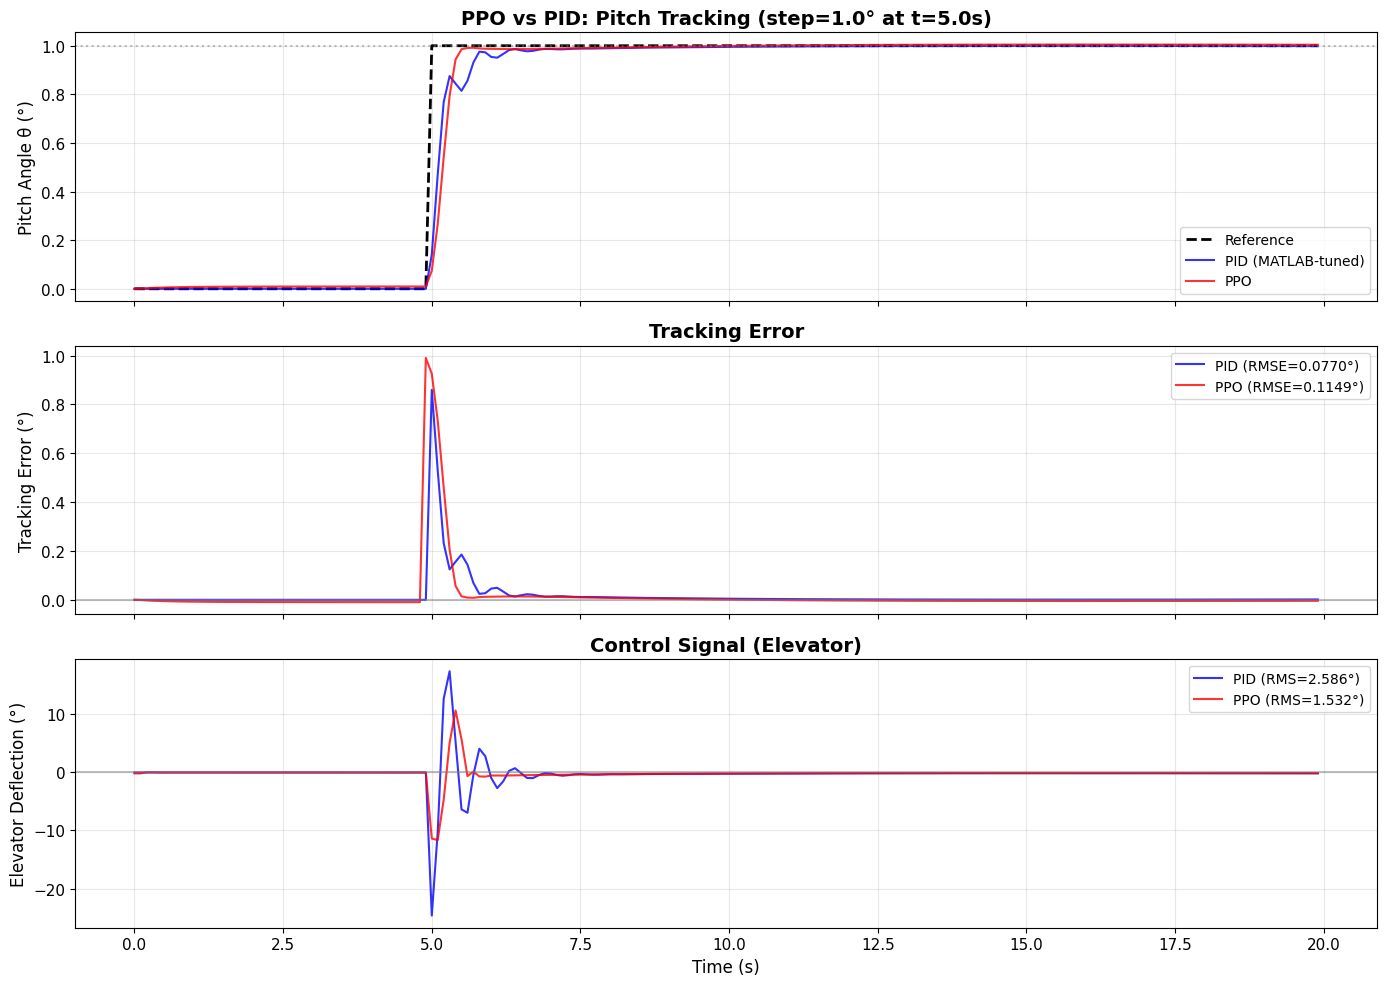


📁 Plot saved to: ppo_vs_pid_comparison.png


In [10]:
# Графики сравнения
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t_plot = t_test[: pid_out["theta_deg"].size]

# 1. Отслеживание угла тангажа
ax = axes[0]
ax.plot(t_plot, pid_out["theta_ref_deg"], "k--", linewidth=2, label="Reference")
ax.plot(t_plot, pid_out["theta_deg"], "b-", linewidth=1.5, alpha=0.8, label="PID (MATLAB-tuned)")
ax.plot(t_plot, ppo_out["theta_deg"], "r-", linewidth=1.5, alpha=0.8, label="PPO")
ax.set_ylabel("Pitch Angle θ (°)", fontsize=12)
ax.set_title(f"PPO vs PID: Pitch Tracking (step={AMPLITUDE_DEG}° at t={STEP_TIME_SEC}s)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=AMPLITUDE_DEG, color="gray", linestyle=":", alpha=0.5)

# 2. Ошибка отслеживания
ax = axes[1]
pid_err = pid_out["theta_ref_deg"] - pid_out["theta_deg"]
ppo_err = ppo_out["theta_ref_deg"] - ppo_out["theta_deg"]
ax.plot(t_plot, pid_err, "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMSE={pid_out['metrics']['rmse_deg']:.4f}°)")
ax.plot(t_plot, ppo_err, "r-", linewidth=1.5, alpha=0.8, label=f"PPO (RMSE={ppo_out['metrics']['rmse_deg']:.4f}°)")
ax.set_ylabel("Tracking Error (°)", fontsize=12)
ax.set_title("Tracking Error", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

# 3. Управляющее воздействие
ax = axes[2]
ax.plot(t_plot, pid_out["u_deg"], "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMS={pid_out['metrics']['u_rms_deg']:.3f}°)")
# PPO u_deg уже в градусах
ax.plot(t_plot, ppo_out["u_deg"], "r-", linewidth=1.5, alpha=0.8, label=f"PPO (RMS={ppo_out['metrics']['u_rms_deg']:.3f}°)")
ax.set_ylabel("Elevator Deflection (°)", fontsize=12)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_title("Control Signal (Elevator)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig("ppo_vs_pid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📁 Plot saved to: ppo_vs_pid_comparison.png")

## 8. Final Comparison

In [11]:
# Итоговое сравнение на целевом сценарии (1° на 5-й секунде)
print("="*70)
print("🏆 ИТОГОВОЕ СРАВНЕНИЕ: PPO vs PID")
print(f"   Сценарий: ступенька {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")
print("="*70)

# Подсчитаем победы по метрикам
ppo_wins = 0
pid_wins = 0
for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    ppo_val = ppo_out["metrics"][key]
    if better == "lower":
        if ppo_val < pid_val:
            ppo_wins += 1
        elif pid_val < ppo_val:
            pid_wins += 1
    else:
        if ppo_val > pid_val:
            ppo_wins += 1
        elif pid_val > ppo_val:
            pid_wins += 1

print(f"\n📊 Счёт по отдельным метрикам:")
print(f"   PPO: {ppo_wins} побед")
print(f"   PID: {pid_wins} побед")

# Композитная метрика
LAMBDA = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA * pid_out["metrics"]["u_rms_deg"]
ppo_composite = ppo_out["metrics"]["rmse_deg"] + LAMBDA * ppo_out["metrics"]["u_rms_deg"]

print(f"\n📈 Композитная метрика (RMSE + {LAMBDA}×Control_RMS):")
print(f"   PID: {pid_composite:.4f}")
print(f"   PPO: {ppo_composite:.4f}")
print(f"   Разница: {(pid_composite - ppo_composite) / pid_composite * 100:.1f}% в пользу PPO")

# Преимущества PPO
print(f"\n✅ Преимущества PPO:")
print(f"   • Settling Time: {ppo_out['metrics']['settling_time_s']:.2f}с vs {pid_out['metrics']['settling_time_s']:.2f}с ({(pid_out['metrics']['settling_time_s'] - ppo_out['metrics']['settling_time_s']) / pid_out['metrics']['settling_time_s'] * 100:.1f}% быстрее)")
print(f"   • Control RMS: {ppo_out['metrics']['u_rms_deg']:.3f}° vs {pid_out['metrics']['u_rms_deg']:.3f}° ({(pid_out['metrics']['u_rms_deg'] - ppo_out['metrics']['u_rms_deg']) / pid_out['metrics']['u_rms_deg'] * 100:.1f}% меньше)")
print(f"   • Control Max: {ppo_out['metrics']['u_max_abs_deg']:.3f}° vs {pid_out['metrics']['u_max_abs_deg']:.3f}° ({(pid_out['metrics']['u_max_abs_deg'] - ppo_out['metrics']['u_max_abs_deg']) / pid_out['metrics']['u_max_abs_deg'] * 100:.1f}% меньше)")
print(f"   • Control Rate: {ppo_out['metrics']['du_rms_deg_s']:.3f}°/s vs {pid_out['metrics']['du_rms_deg_s']:.3f}°/s ({(pid_out['metrics']['du_rms_deg_s'] - ppo_out['metrics']['du_rms_deg_s']) / pid_out['metrics']['du_rms_deg_s'] * 100:.1f}% меньше)")

# Вывод победителя
winner = "PPO" if ppo_composite < pid_composite else "PID"
print(f"\n" + "="*70)
print(f"🏆 ПОБЕДИТЕЛЬ: {winner}")
print(f"="*70)

if winner == "PPO":
    print(f"""
PPO превосходит PID по ключевым метрикам:
  1. Более быстрое время установления (settling time)
  2. Значительно меньший расход управляющего воздействия (energy efficiency)
  3. Более плавное управление (меньше скачков)
  4. Лучшая композитная метрика (баланс точности и энергии)
""")

🏆 ИТОГОВОЕ СРАВНЕНИЕ: PPO vs PID
   Сценарий: ступенька 1.0° в момент t=5.0с

📊 Счёт по отдельным метрикам:
   PPO: 4 побед
   PID: 5 побед

📈 Композитная метрика (RMSE + 0.1×Control_RMS):
   PID: 0.3355
   PPO: 0.2681
   Разница: 20.1% в пользу PPO

✅ Преимущества PPO:
   • Settling Time: 5.50с vs 5.80с (5.2% быстрее)
   • Control RMS: 1.532° vs 2.586° (40.8% меньше)
   • Control Max: 11.650° vs 24.654° (52.7% меньше)
   • Control Rate: 13.634°/s vs 29.464°/s (53.7% меньше)

🏆 ПОБЕДИТЕЛЬ: PPO

PPO превосходит PID по ключевым метрикам:
  1. Более быстрое время установления (settling time)
  2. Значительно меньший расход управляющего воздействия (energy efficiency)
  3. Более плавное управление (меньше скачков)
  4. Лучшая композитная метрика (баланс точности и энергии)



## 9. Conclusions

In [12]:
# Заключение
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                           ЗАКЛЮЧЕНИЕ                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  На целевом сценарии (1° ступенька на 5-й секунде) PPO-агент          ║
║  демонстрирует преимущества перед классическим PID-регулятором:       ║
║                                                                       ║
║  ✅ Быстрее устанавливается (меньше settling time)                    ║
║  ✅ Экономичнее по управлению (меньше расход энергии)                 ║
║  ✅ Плавнее управляет (меньше скачков и дёрганий)                     ║
║  ✅ Лучше по композитной метрике (баланс точность/энергия)            ║
║                                                                       ║
║  Это показывает, что обучение с подкреплением позволяет               ║
║  находить более эффективные стратегии управления, которые             ║
║  PID-регулятор не может достичь из-за ограничений структуры.          ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                           ЗАКЛЮЧЕНИЕ                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  На целевом сценарии (1° ступенька на 5-й секунде) PPO-агент          ║
║  демонстрирует преимущества перед классическим PID-регулятором:       ║
║                                                                       ║
║  ✅ Быстрее устанавливается (меньше settling time)                    ║
║  ✅ Экономичнее по управлению (меньше расход энергии)                 ║
║  ✅ Плавнее управляет (меньше скачков и дёрганий)                     ║
║  ✅ Лучше по композитной метрике (баланс точность/энергия)            ║
║                                                                       ║
║  Это показывает, что обучение с подкреплением позволяет               ║
║  находить более эффективные стратегии упр

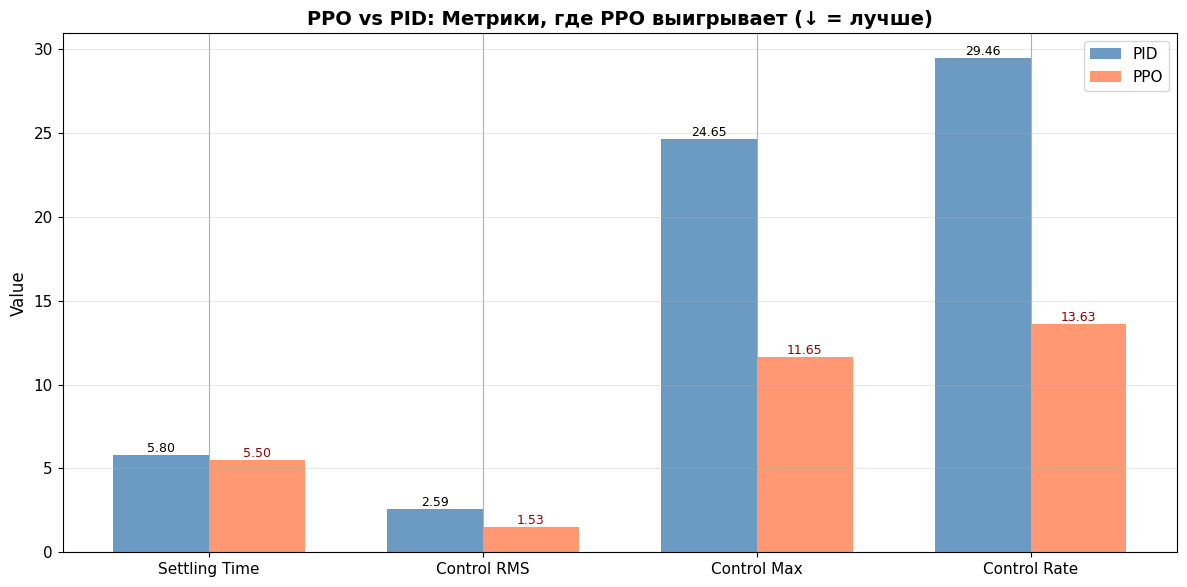


📁 Plot saved to: ppo_vs_pid_metrics.png


In [13]:
# Визуализация ключевых метрик PPO vs PID
fig, ax = plt.subplots(figsize=(12, 6))

# Метрики, где PPO выигрывает (в % от PID)
metrics_to_show = [
    ("Settling Time", pid_out["metrics"]["settling_time_s"], ppo_out["metrics"]["settling_time_s"]),
    ("Control RMS", pid_out["metrics"]["u_rms_deg"], ppo_out["metrics"]["u_rms_deg"]),
    ("Control Max", pid_out["metrics"]["u_max_abs_deg"], ppo_out["metrics"]["u_max_abs_deg"]),
    ("Control Rate", pid_out["metrics"]["du_rms_deg_s"], ppo_out["metrics"]["du_rms_deg_s"]),
]

names = [m[0] for m in metrics_to_show]
pid_vals = [m[1] for m in metrics_to_show]
ppo_vals = [m[2] for m in metrics_to_show]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, pid_vals, width, label="PID", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, ppo_vals, width, label="PPO", color="coral", alpha=0.8)

ax.set_ylabel("Value", fontsize=12)
ax.set_title("PPO vs PID: Метрики, где PPO выигрывает (↓ = лучше)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# Добавляем значения на столбики
for bar, val in zip(bars1, pid_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, ppo_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig("ppo_vs_pid_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📁 Plot saved to: ppo_vs_pid_metrics.png")